In [ ]:
import math

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


from tqdm.auto import tqdm

from nltk.stem import PorterStemmer
import spacy
from transformers import BertTokenizer
import torch
%matplotlib inline

In [16]:
df = pd.read_csv('wikIR1k/documents.csv')

In [12]:
def basic_stats(df: pd.DataFrame):
    result = {}

    result["#documents"] = len(df)

    words = df.text_right.map(lambda x: x.split())

    result["#words"] = int(words.map(lambda x: len(x)).sum())
    result["avg document length"] = float(words.map(lambda x: len(x)).mean())

    unique_words = set()
    words.map(lambda x: unique_words.update(x))
    result["#unique words"] = len(unique_words)

    result["avg word length"] = float(
        words.map(lambda x: sum(map(len, x)) / len(x)).mean()
    )
    result["avg uniq word length"] = sum(map(len, unique_words)) / len(unique_words)

    return result

In [4]:
basic_stats(df)

{'#documents': 369721,
 '#words': 73093729,
 'avg document length': 197.69969517555128,
 '#unique words': 794568,
 'avg word length': 4.795060646964498,
 'avg uniq word length': 7.714459932944695}

In [ ]:
freq = {}

for words in tqdm(df.text_right):
    for word in words.split():
        freq[word] = freq.get(word, 0) + 1
freq = dict(sorted(freq.items(), key=lambda x: x[1], reverse=True))
freq

  0%|          | 0/369721 [00:00<?, ?it/s]

{'the': 5311943,
 'of': 2532382,
 'in': 2355417,
 'and': 2231007,
 'a': 1557760,
 'to': 1407261,
 'was': 1078183,
 'he': 685303,
 'is': 676829,
 'as': 661622,
 'for': 616110,
 'on': 610583,
 'with': 535843,
 'by': 526627,
 's': 497472,
 'at': 482839,
 'his': 440633,
 'from': 432326,
 'it': 398308,
 'that': 306808,
 'an': 279228,
 'which': 221057,
 'first': 217204,
 'are': 206921,
 'were': 205684,
 'has': 195167,
 'also': 186055,
 'she': 184297,
 'after': 166616,
 'its': 161439,
 'this': 158773,
 'one': 157573,
 'her': 155433,
 'had': 154729,
 'or': 146622,
 'be': 144753,
 'new': 139850,
 'two': 136427,
 'their': 132193,
 'who': 125172,
 'but': 121816,
 'school': 119897,
 'they': 115317,
 'university': 107386,
 'been': 107365,
 'during': 106057,
 'when': 102478,
 'have': 100236,
 'not': 96211,
 'time': 95373,
 'other': 93512,
 'all': 91953,
 'where': 91520,
 '1': 89967,
 'years': 88565,
 'year': 85032,
 'into': 84785,
 'there': 83154,
 'later': 80738,
 'became': 80151,
 'city': 77682,
 

In [6]:
stopwords = set(open("NLTK's list of english stopwords").read().split())

stop_count = 0
for word in stopwords:
    stop_count += freq.get(word, 0)
stop_count

29387785

In [7]:
set([*freq.keys()][:30]) - set(stopwords)

{'also', 'first'}

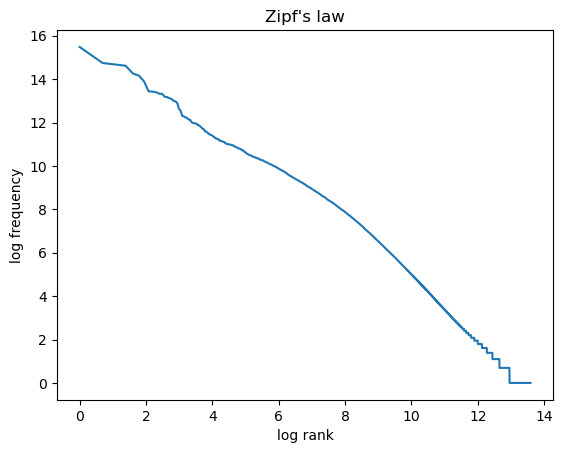

In [ ]:
plt.plot(
    [math.log(x) for x in range(1, len(freq) + 1)], [math.log(x) for x in freq.values()]
)

plt.title("Zipf's law")
plt.xlabel("log rank")
plt.ylabel("log frequency")
plt.show()

  0%|          | 0/369721 [00:00<?, ?it/s]

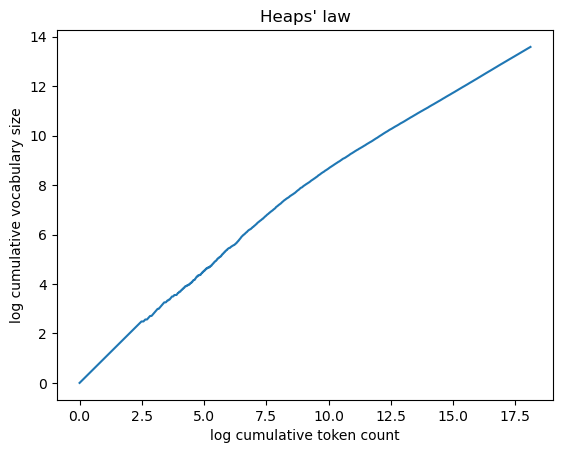

In [ ]:
uniq_words = set()
uniq_words_count = []

for words in tqdm(df.text_right):
    for word in words.split():
        uniq_words.add(word)
        uniq_words_count.append(len(uniq_words))

plt.plot(
    [math.log(x) for x in range(1, len(uniq_words_count) + 1)],
    [math.log(x) for x in uniq_words_count],
)

plt.title("Heaps' law")
plt.xlabel("log word count")
plt.ylabel("log unique word count")
plt.show()

In [17]:
bigram_freq = {}

for words in tqdm(df.text_right):
    word_list = words.split()
    for i in range(len(word_list) - 1):
        bigram = (word_list[i], word_list[i + 1])
        bigram_freq[bigram] = bigram_freq.get(bigram, 0) + 1
bigram_freq = dict(sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True))
len(bigram_freq), bigram_freq

  0%|          | 0/369721 [00:00<?, ?it/s]

(12993004,
 {('of', 'the'): 768320,
  ('in', 'the'): 546863,
  ('to', 'the'): 256451,
  ('at', 'the'): 201351,
  ('and', 'the'): 170394,
  ('on', 'the'): 169708,
  ('he', 'was'): 163554,
  ('as', 'a'): 163073,
  ('for', 'the'): 159502,
  ('by', 'the'): 130810,
  ('with', 'the'): 120118,
  ('from', 'the'): 115219,
  ('the', 'first'): 104264,
  ('it', 'was'): 101387,
  ('as', 'the'): 96915,
  ('it', 'is'): 95880,
  ('is', 'a'): 82161,
  ('was', 'a'): 78342,
  ('in', 'a'): 76786,
  ('one', 'of'): 70278,
  ('was', 'the'): 69881,
  ('of', 'a'): 69345,
  ('with', 'a'): 63880,
  ('is', 'the'): 63672,
  ('to', 'be'): 62139,
  ('and', 'was'): 58478,
  ('during', 'the'): 56159,
  ('and', 'a'): 56121,
  ('part', 'of'): 54180,
  ('the', 'united'): 49922,
  ('united', 'states'): 48952,
  ('university', 'of'): 45096,
  ('was', 'born'): 45000,
  ('such', 'as'): 42905,
  ('the', 'university'): 42096,
  ('has', 'been'): 41300,
  ('of', 'his'): 41171,
  ('she', 'was'): 39690,
  ('to', 'a'): 39608,
  ('a

In [ ]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.stemmer = PorterStemmer()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return " ".join(
            self.stemmer.stem(word) for word in self.df.iloc[idx].text_right.split()
        )


df = pd.read_csv("wikIR1k/documents.csv")
dataset = Dataset(df)
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=32, shuffle=False, num_workers=8
)
tokenized_words = []
for batch in tqdm(dataloader):
    tokenized_words.extend(batch)

df["text_right"] = tokenized_words

basic_stats(df)

  0%|          | 0/369721 [00:00<?, ?it/s]

{'#documents': 369721,
 '#words': 73093729,
 'avg document length': 197.69969517555128,
 '#unique words': 684579,
 'avg word length': 4.2645923273274,
 'avg uniq word length': 7.341918171606199}

In [13]:
df = pd.read_csv("wikIR1k/documents.csv")

texts = df["text_right"].fillna("").astype(str).tolist()

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

lemmatized = []
for doc in tqdm(nlp.pipe(texts, batch_size=256, n_process=8), total=len(texts)):
    lemmatized.append(" ".join(token.lemma_ for token in doc))

df["text_right"] = lemmatized

basic_stats(df)

{'#documents': 369721,
 '#words': 73106364,
 'avg document length': 197.73386959355838,
 '#unique words': 758817,
 'avg word length': 4.586605568707449,
 'avg uniq word length': 7.636306250387116}

In [ ]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return " ".join(self.tokenizer.tokenize(self.df.iloc[idx].text_right))


df = pd.read_csv("wikIR1k/documents.csv")
dataset = Dataset(df)
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=32, shuffle=False, num_workers=8
)
tokenized_words = []
for batch in tqdm(dataloader):
    tokenized_words.extend(batch)

df["text_right"] = tokenized_words

basic_stats(df)

  0%|          | 0/11554 [00:00<?, ?it/s]

{'#documents': 369721,
 '#words': 81185427,
 'avg document length': 219.5856524243957,
 '#unique words': 27528,
 'avg word length': 4.523360971162666,
 'avg uniq word length': 6.633500435919791}